In [1]:
import pandas as pd
import numpy as np
import os, ast
os.chdir('..')
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
vdj = pd.read_csv('data/vdj_cleaned_subset_for_MI_no-small-study.csv', index_col = 0)
print(vdj.head())
print(vdj.shape)
epitope_counts = vdj['Epitope'].value_counts()
print(epitope_counts)
epitopes = vdj['Epitope'].unique().tolist()

   Unnamed: 0  complex.id Gene-a           CDR3-a       V-a     J-a  \
0          13          14    TRA    CAYTVLGNEKLTF  TRAV38-1  TRAJ48   
1          14          15    TRA  CAVAGYGGSQGNLIF  TRAV12-2  TRAJ42   
2          15          16    TRA     CAVSFGNEKLTF  TRAV12-2  TRAJ48   
3          16          17    TRA  CAVTHYGGSQGNLIF  TRAV12-2  TRAJ42   
4          17          18    TRA    CAGGGGGADGLTF  TRAV12-2  TRAJ45   

       Species     MHC A MHC B MHC class  ... cdr2a_IMGTgaps cdr2b_IMGTgaps  \
0  HomoSapiens  HLA-A*02   B2M      MHCI  ...     QEAY--KQQN     SYD----VKM   
1  HomoSapiens  HLA-A*02   B2M      MHCI  ...     IYS----NGD     SYD----VKM   
2  HomoSapiens  HLA-A*02   B2M      MHCI  ...     IYS----NGD     SYD----VKM   
3  HomoSapiens  HLA-A*02   B2M      MHCI  ...     IYS----NGD     SYD----VKM   
4  HomoSapiens  HLA-A*02   B2M      MHCI  ...     IYS----NGD     SYD----VKM   

    cdr3a_IMGTgaps   cdr3b_IMGTgaps len_cdr3a len_cdr3b len_cdr3a_IMGTgaps  \
0  CAYTVLG--NEKLTF  

In [3]:
MI = pd.DataFrame()

for ep in epitopes + ['background']:
    df = pd.read_csv('data/output/mutual_info/mutual_info_' + ep + '_w_studyspecific_shuffle_wdupl.csv')
    MI = pd.concat([MI, df])

ep = 'Tanno::A1::naive'
df = pd.read_csv('data/output/mutual_info/mutual_info_' + ep + '_wdupl.csv')
MI = pd.concat([MI, df])

In [4]:
MI = MI.set_index(['type', 'Unnamed: 0'])
MI.columns = [int(x) for x in MI.columns]
MI = MI.sort_index(axis=1)
# print(MI)

In [5]:
MI1 = MI.dropna(axis=0, how='all')
MI1 = MI1.replace(pd.NA, '[]')

In [6]:
# print(MI1)

In [7]:
for c in MI1.columns:
    MI1[c] = [ast.literal_eval(x) for x in MI1[c]]
    MI1[c] = [x if type(x) == list else [x]*10 for x in MI1[c]]
# print(MI1)

In [8]:
MI1 = MI1.reset_index(names = ['type','epitope'])
MI1['shuffle'] = ['shuffle' if 'shuffle' in x else 'real' for x in MI1['epitope']]
MI1['epitope'] = [x.split('_')[0] for x in MI1['epitope']]
# print(MI1)

In [9]:
MI2 = MI1.set_index(['epitope', 'shuffle', 'type']).apply(pd.Series).stack().explode()
MI2 = MI2.reset_index().rename(columns = {'level_3':'subsample', 0:'value'}).dropna(subset='value')

In [10]:
MI2['1/N'] = 1/MI2['subsample']

In [13]:
def fit_linear(mydf, title, ax):    
    single_vals = []
    def _fit(mydf1):
        df = mydf1.copy()
        df = df.dropna(subset=['value'])
        x = np.array(df['1/N'])
        myfit = np.polyfit(x, df['value'].astype('float64'), deg=1)
        p = np.poly1d(myfit)
        x_unique = np.linspace(0, max(x))
        y_unique = p(x_unique)
        # print(p, x_unique, y_unique)
        # print(x, df['value'].astype('float64'))
        assert p(0) == myfit[1]
        return(x_unique, y_unique, p(0))
    
    for j in ['real', 'shuffle']:
        if j == 'real':
            linestyle = '-'
            marker = 'o'
            s = 30
            col='r'
        else:
            linestyle = '-'
            marker = 'X'
            s = 30
            col='k'
        mydf0 = mydf.loc[mydf.shuffle == j]
        x_unique, y_unique, single_val = _fit(mydf0)    
        xy = pd.DataFrame([x_unique, y_unique], index = ['x', 'y']).T
        sns.scatterplot(data = mydf0, x = '1/N', y='value', ax=ax, alpha = 0.5, marker = marker, c=col, s = s, legend=None)
        sns.lineplot(data=xy, x='x', y='y', color = col, linestyle = linestyle, alpha = 0.5,  label = j, ax=ax)
        single_vals.append(single_val)
        # ax.scatter(0, single_val, marker = marker, color = col, s = 300, alpha = 0.5)
    ax.set_title(title)
    ax.set_xlim(0,0.041)
    # ax.set_yscale('log')
    # ax.set_xscale('log')

    return(single_vals)
    

In [ ]:
f2 = 'data/output/figures/'

(64200, 6)
['cdr3a-cdr3b', 'Va-Vb', 'Ja-Jb', 'Va-Ja', 'Vb-Jb', 'Va-Jb', 'Vb-Ja', 'Va-CDR3a', 'Vb-CDR3b', 'Ja-CDR3a', 'Jb-CDR3b', 'Va-CDR3b', 'Vb-CDR3a', 'Ja-CDR3b', 'Jb-CDR3a']
(64200, 6)
ASNENMETM


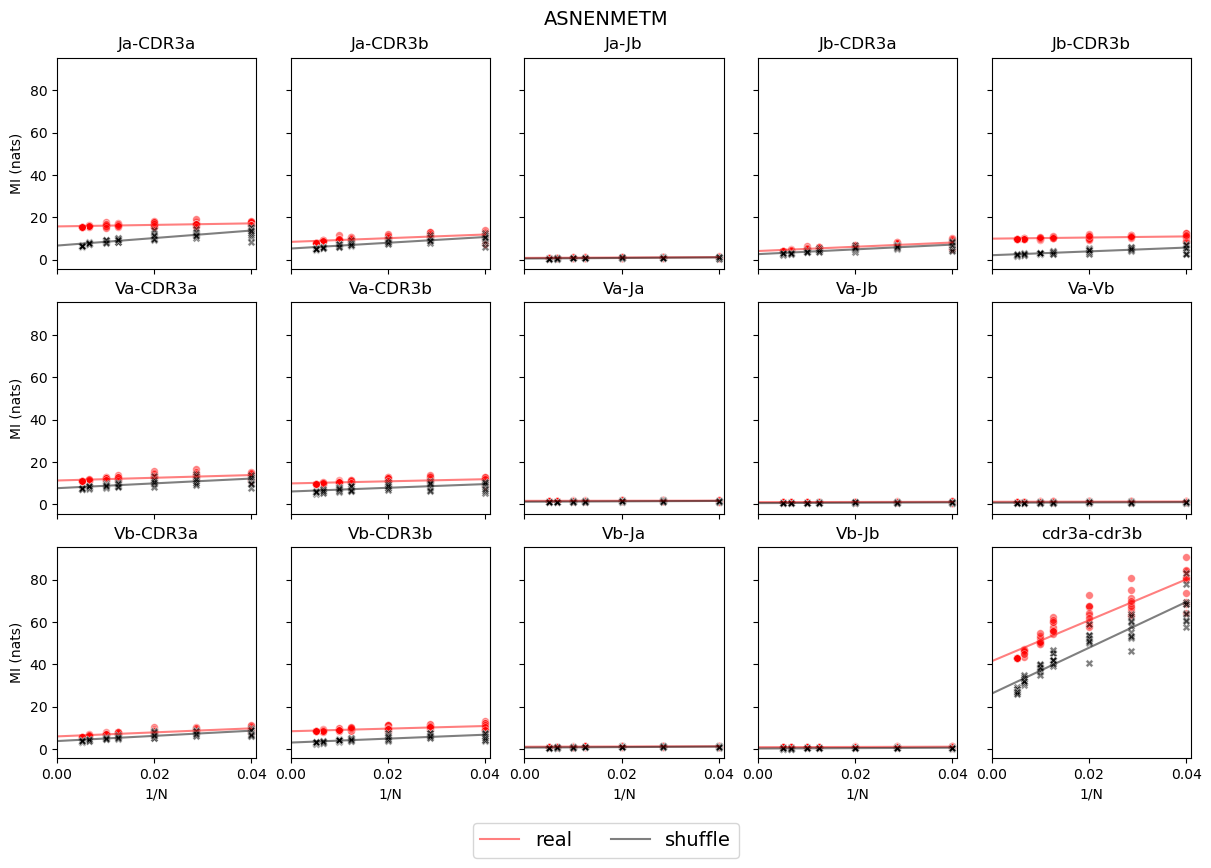

ATDALMTGF


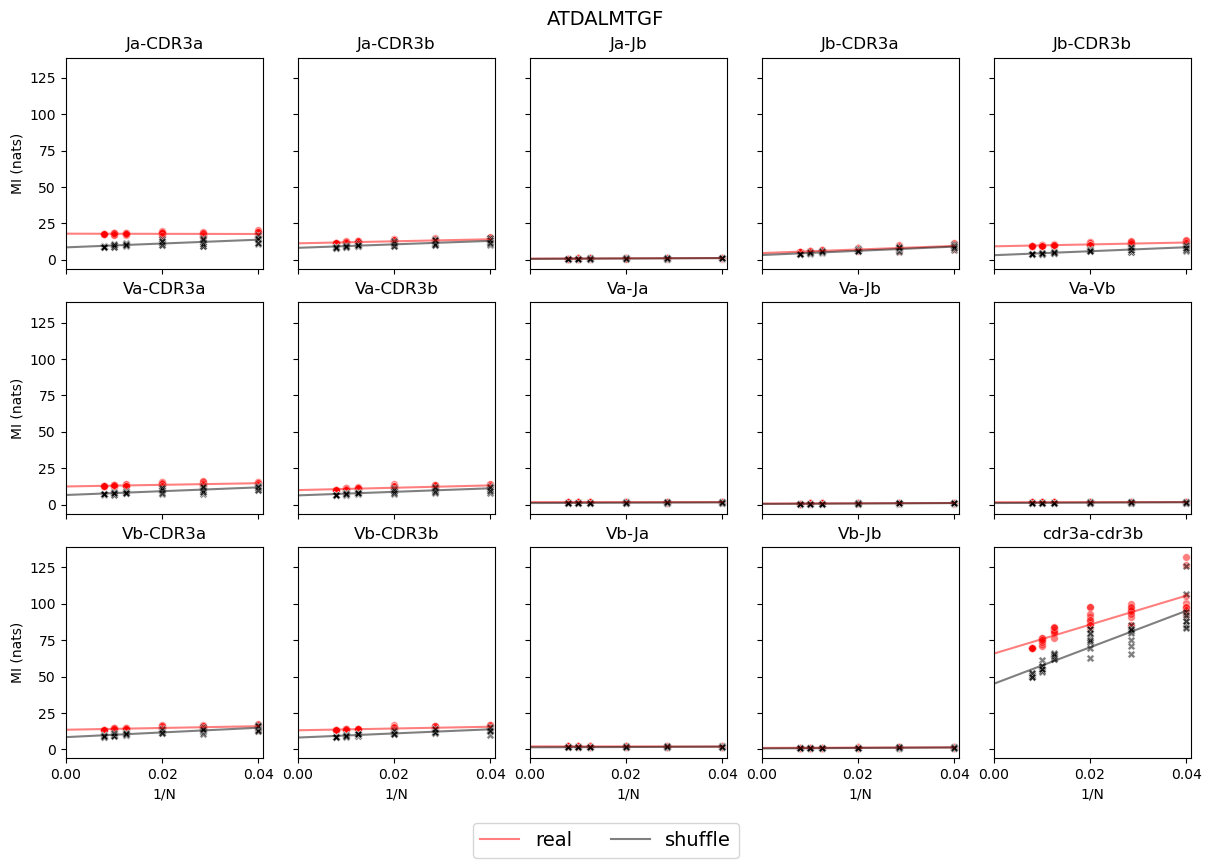

AVFDRKSDAK


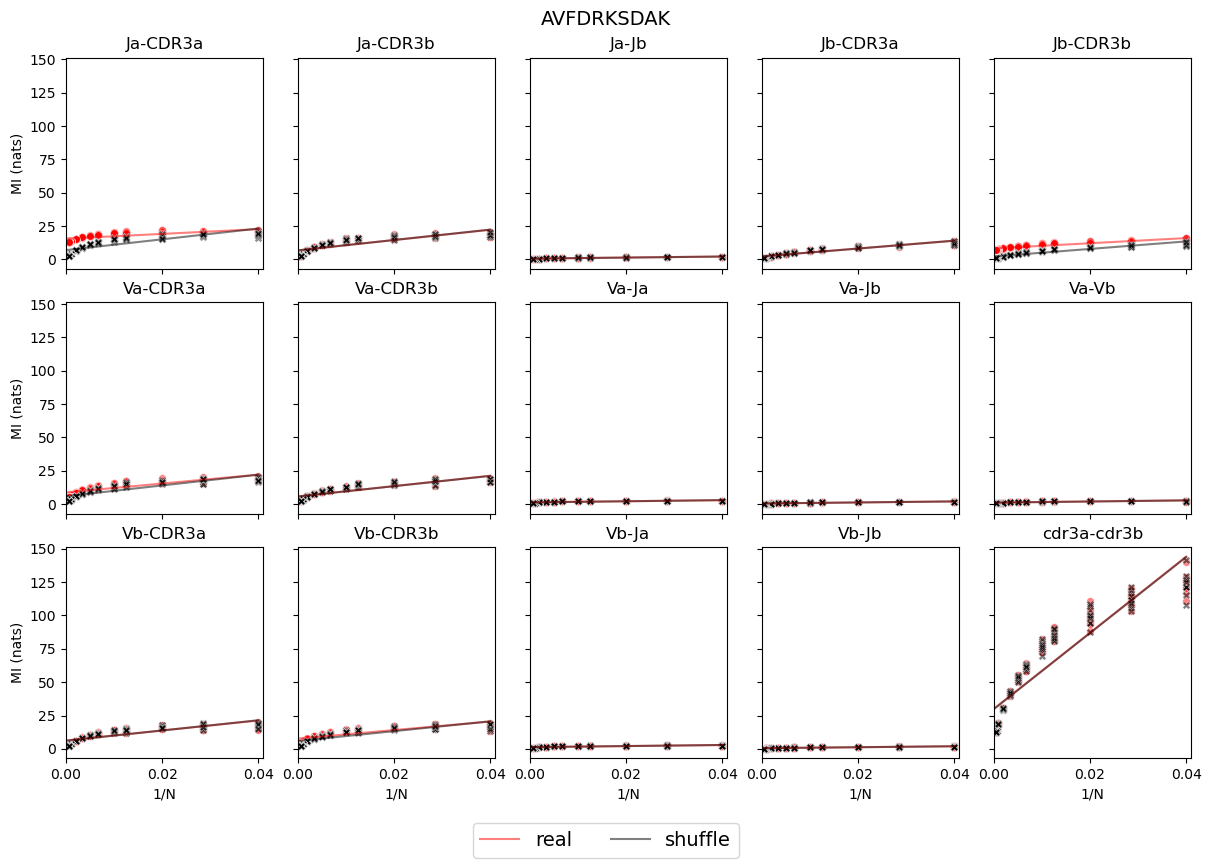

CINGVCWTV


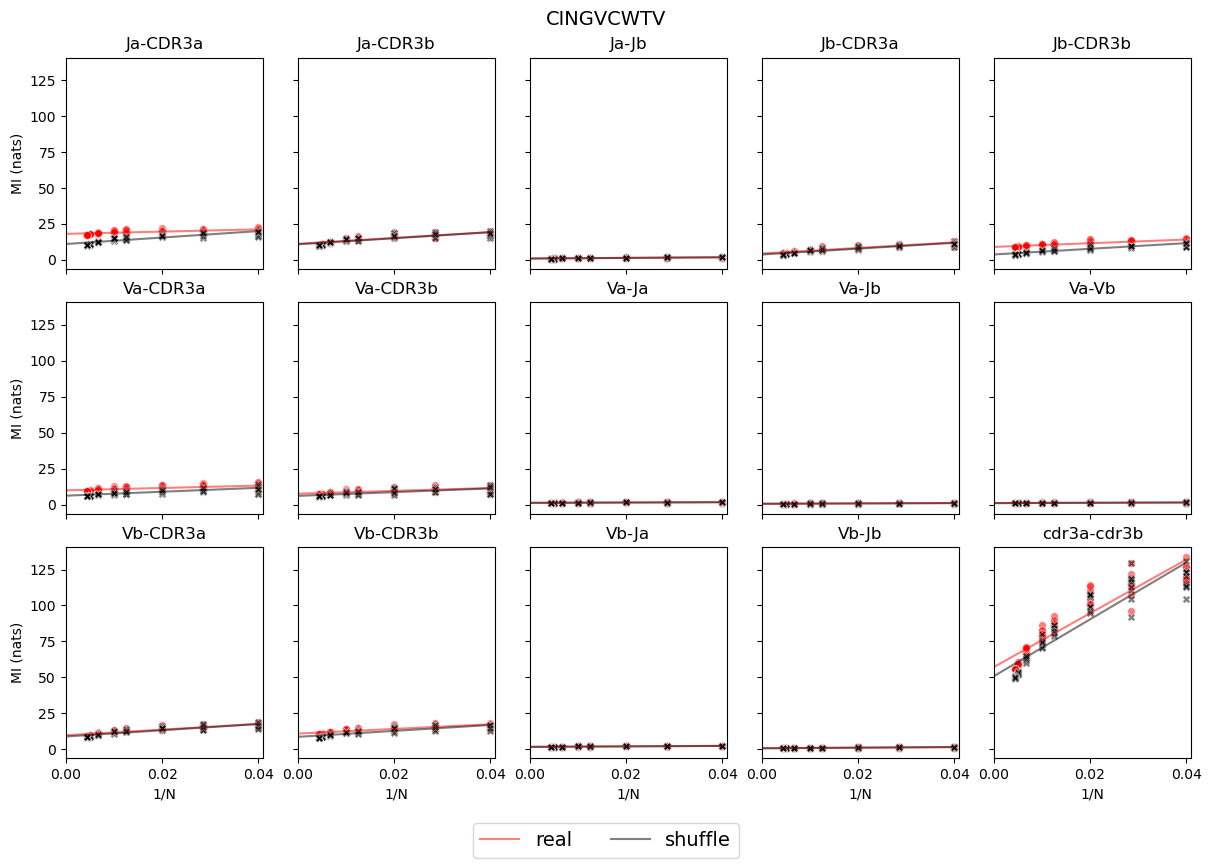

ELAGIGILTV


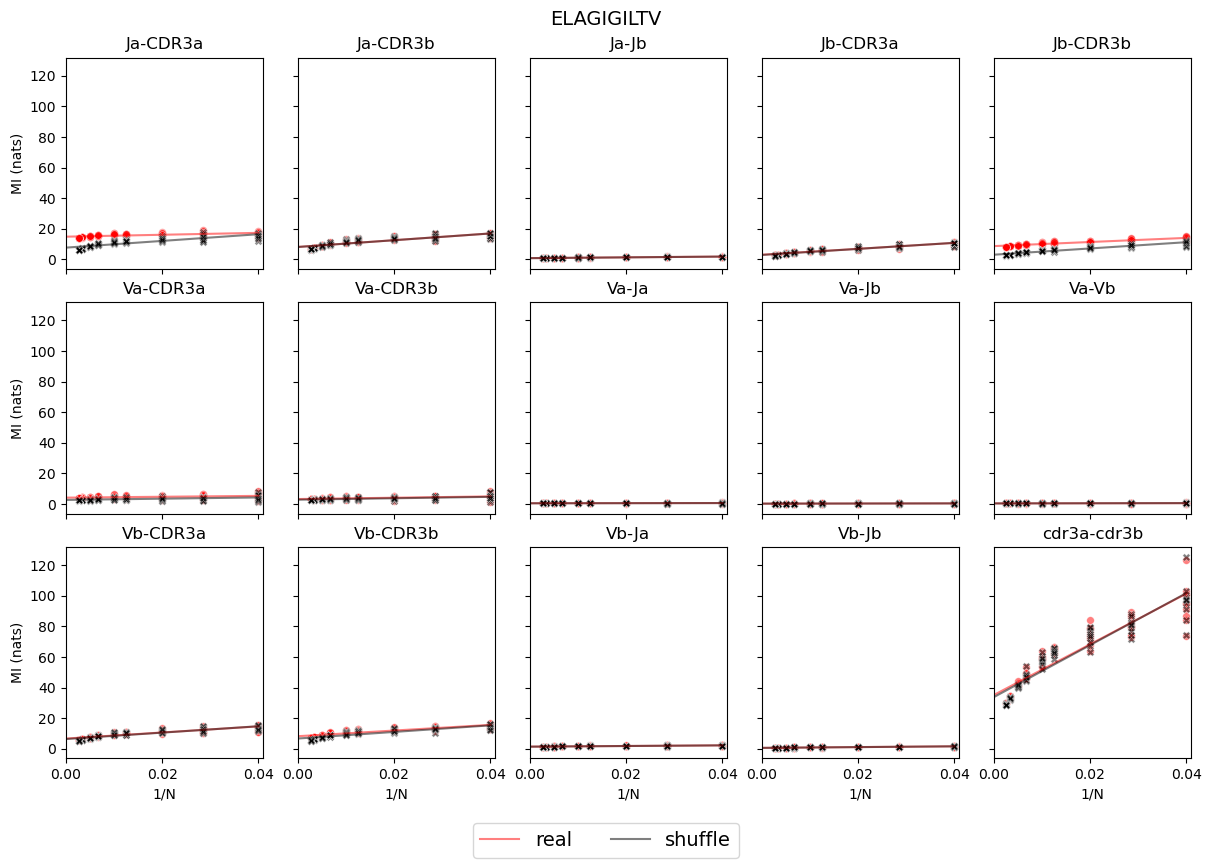

GILGFVFTL


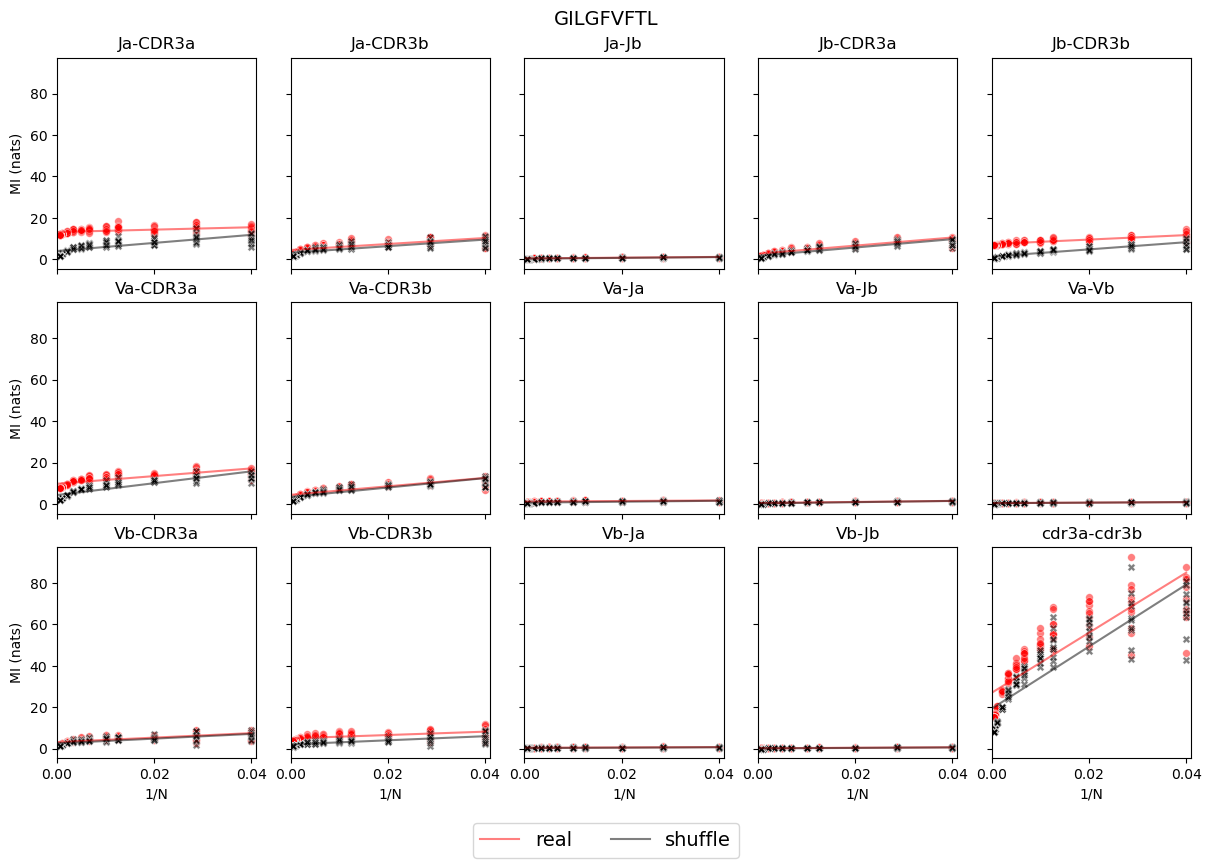

GLCTLVAML


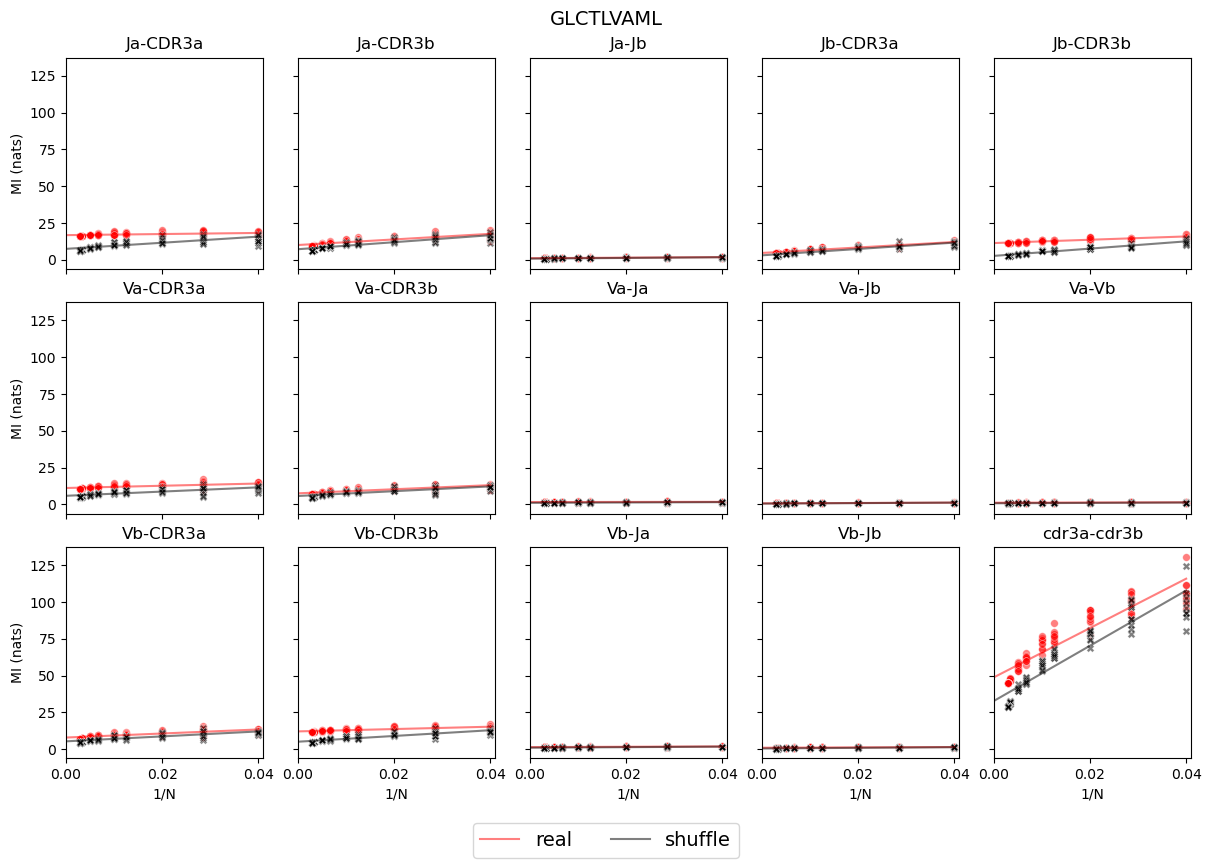

HGIRNASFI


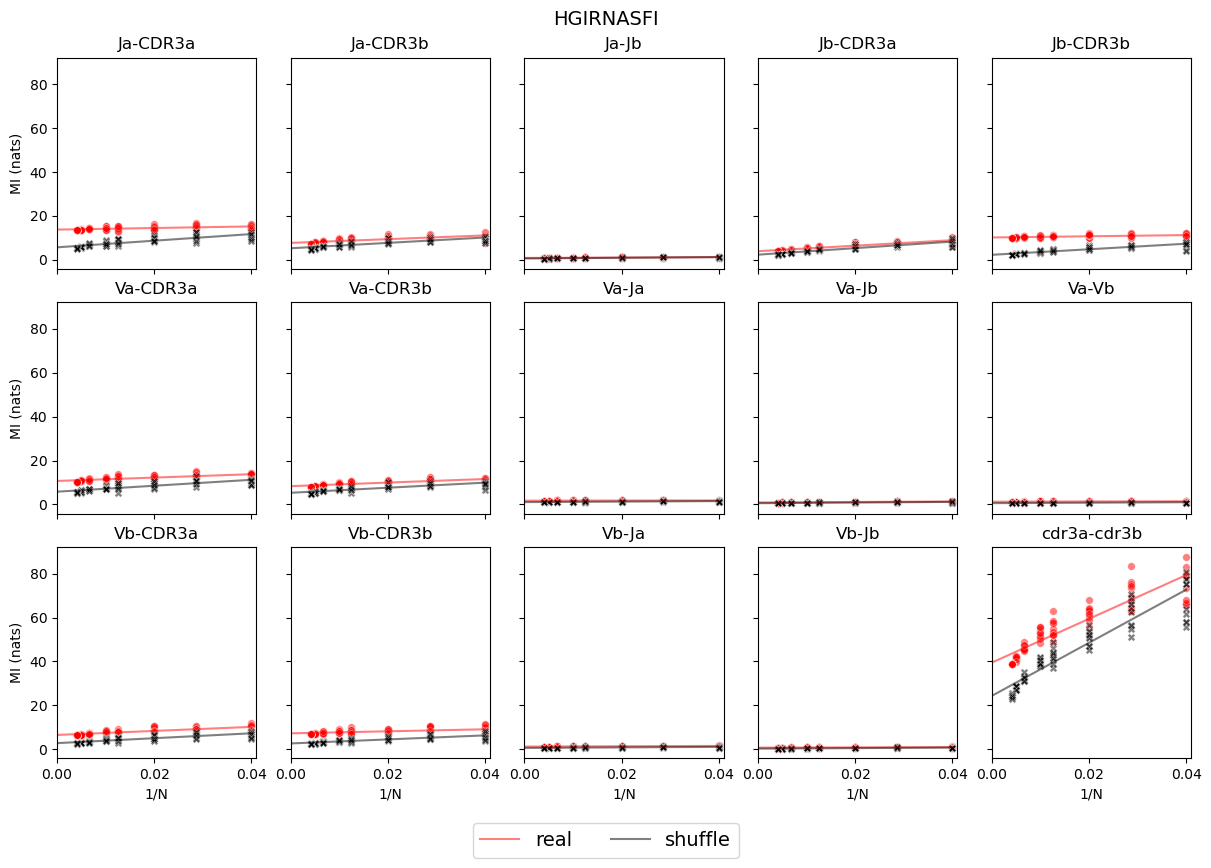

IVTDFSVIK


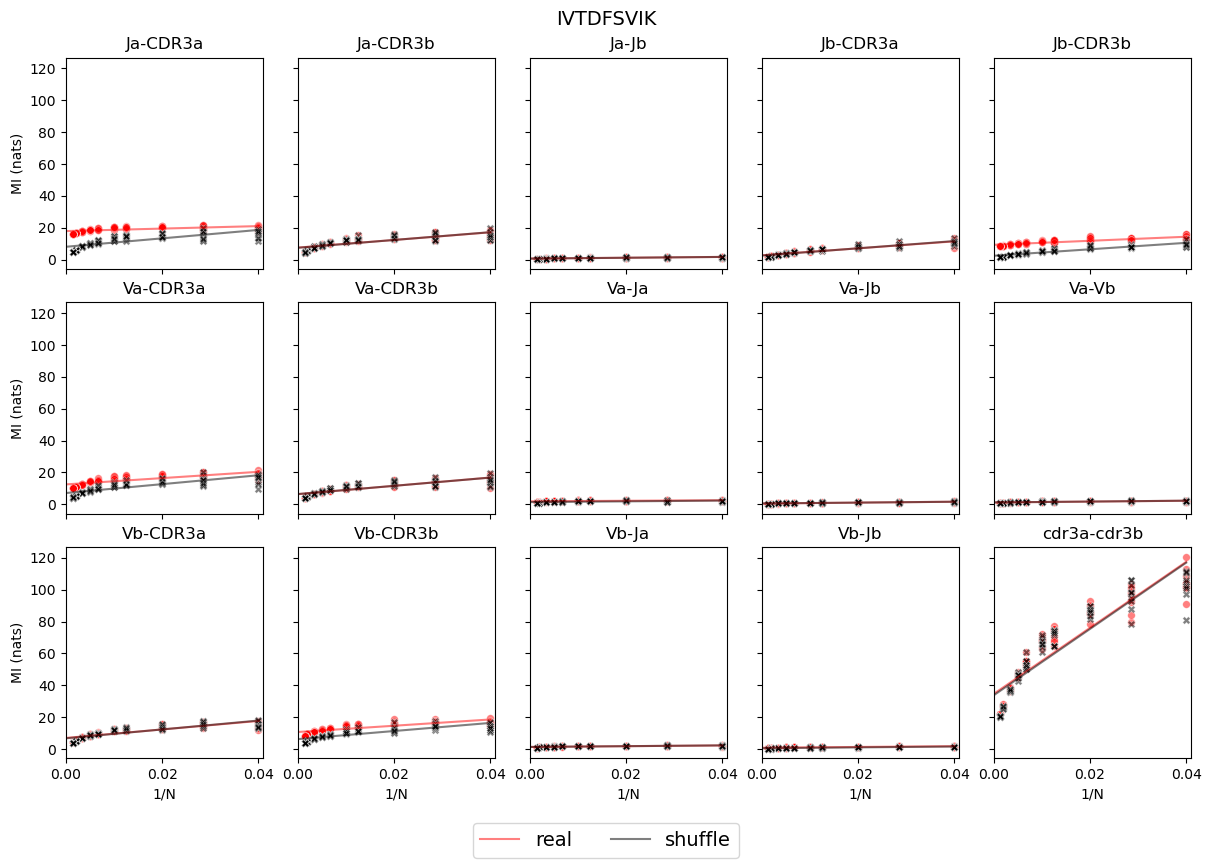

KSKRTPMGF


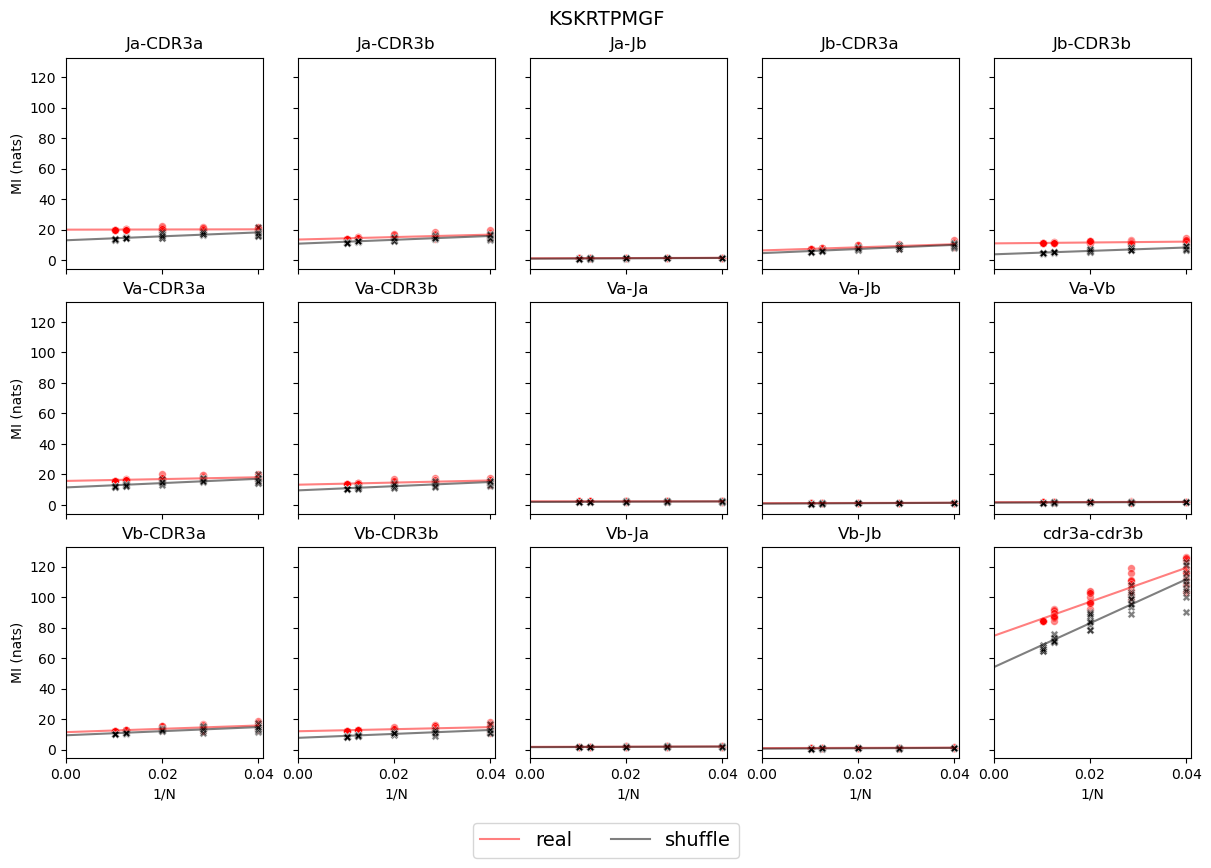

LLWNGPMAV


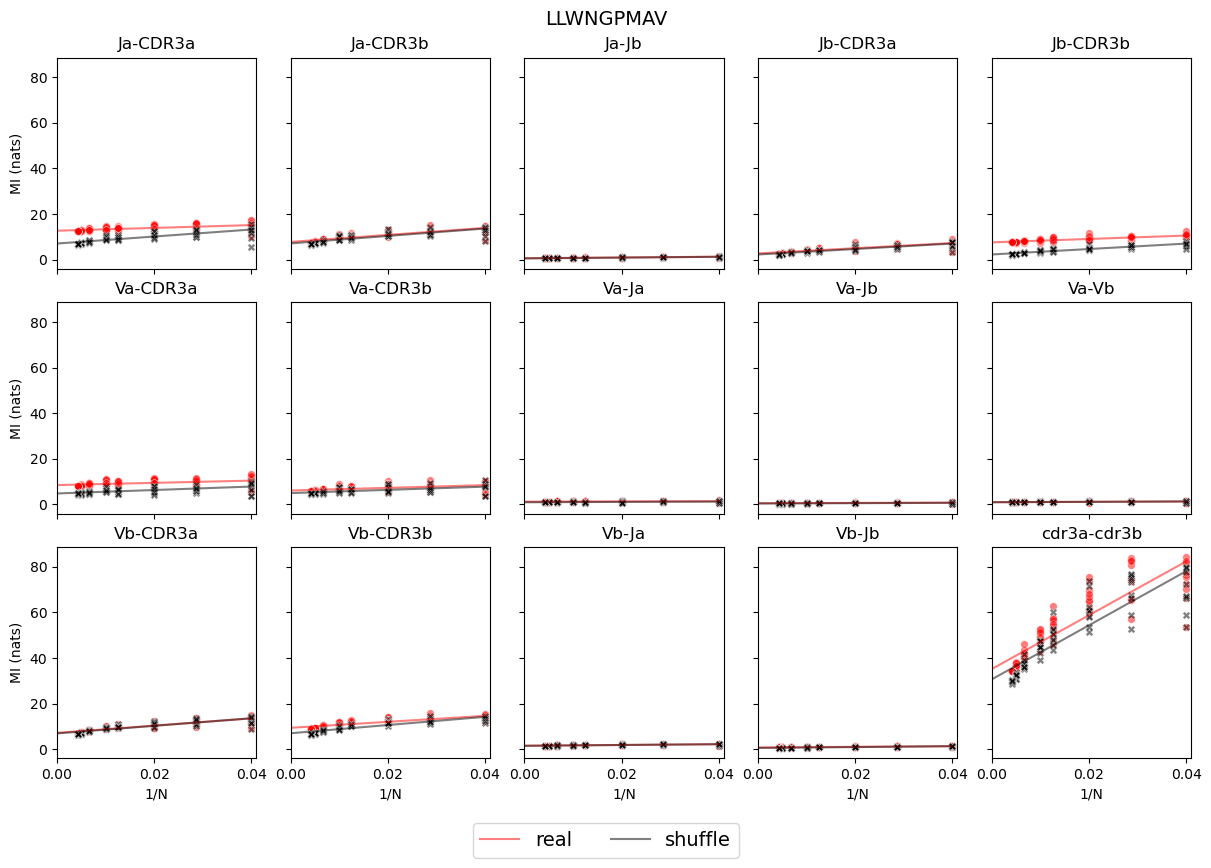

LSLRNPILV


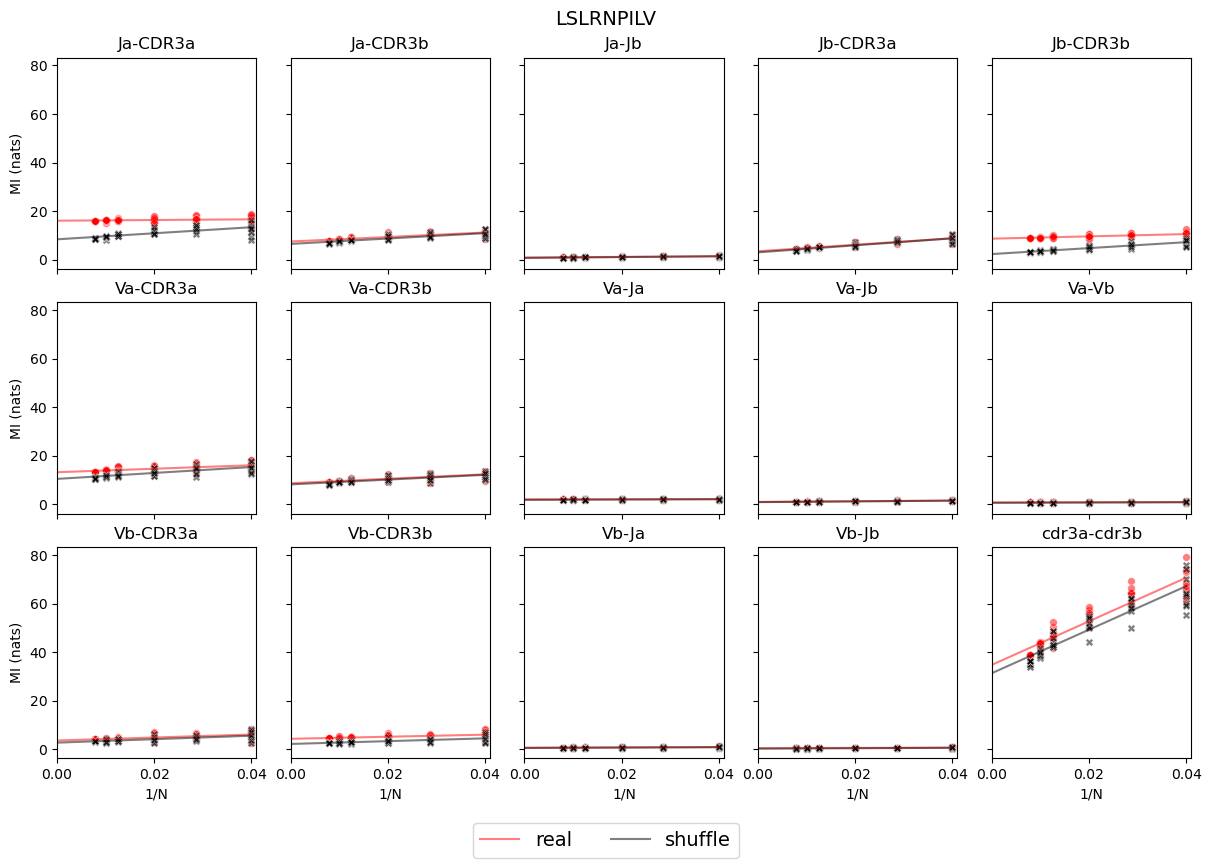

LTDEMIAQY


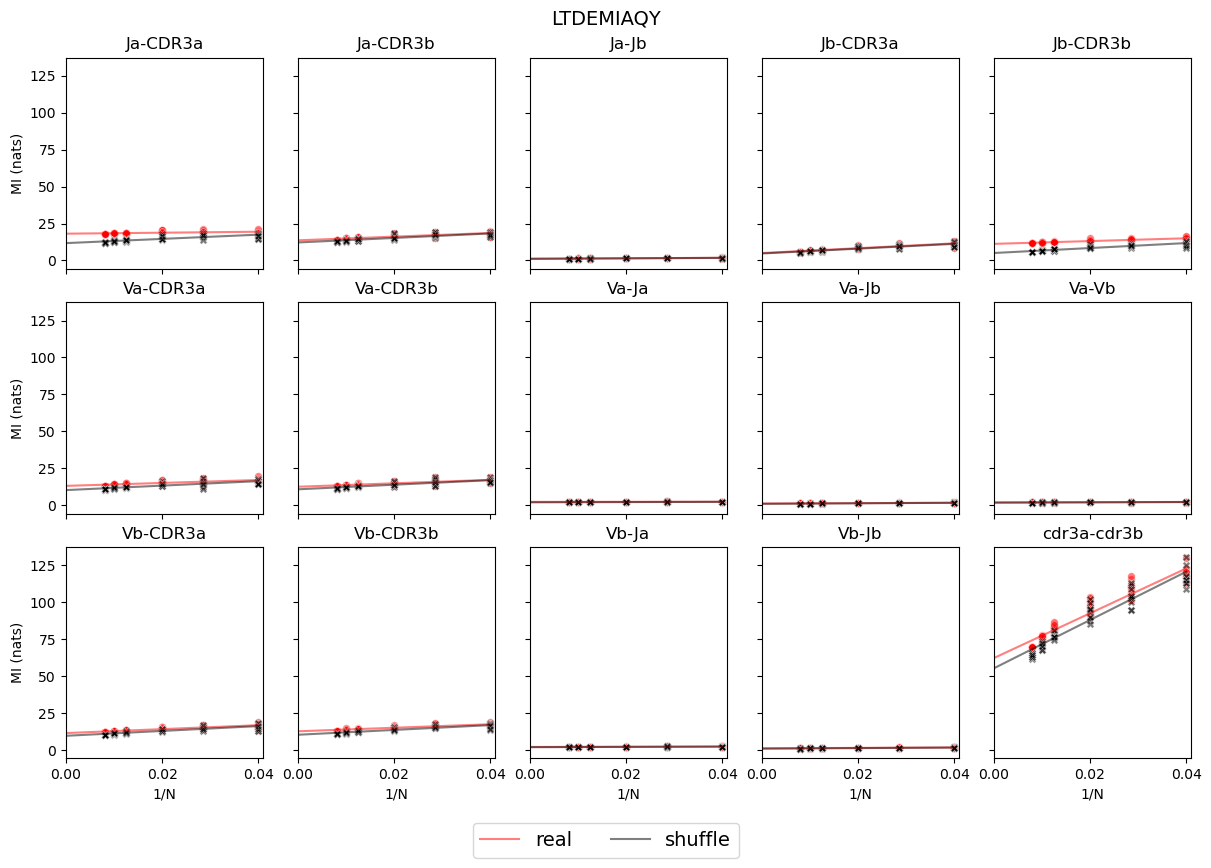

NLVPMVATV


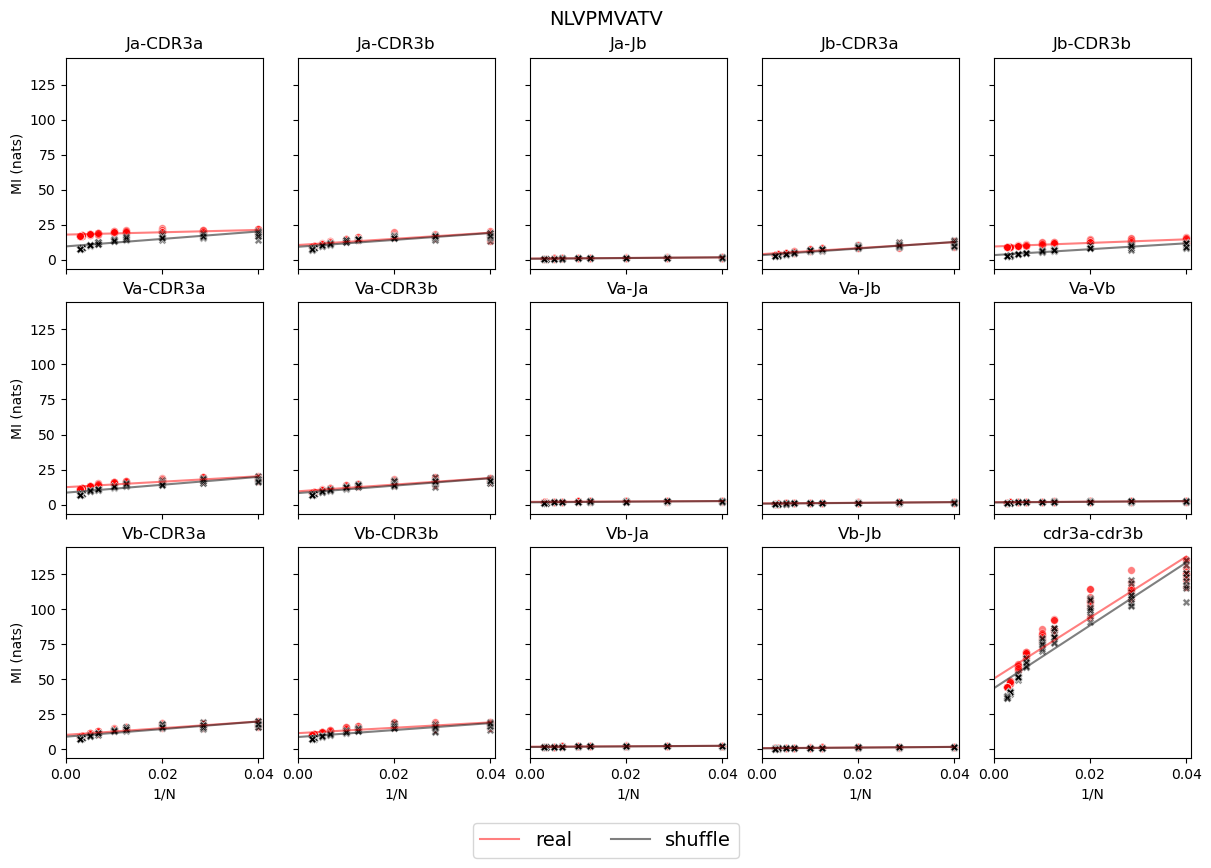

RAKFKQLL


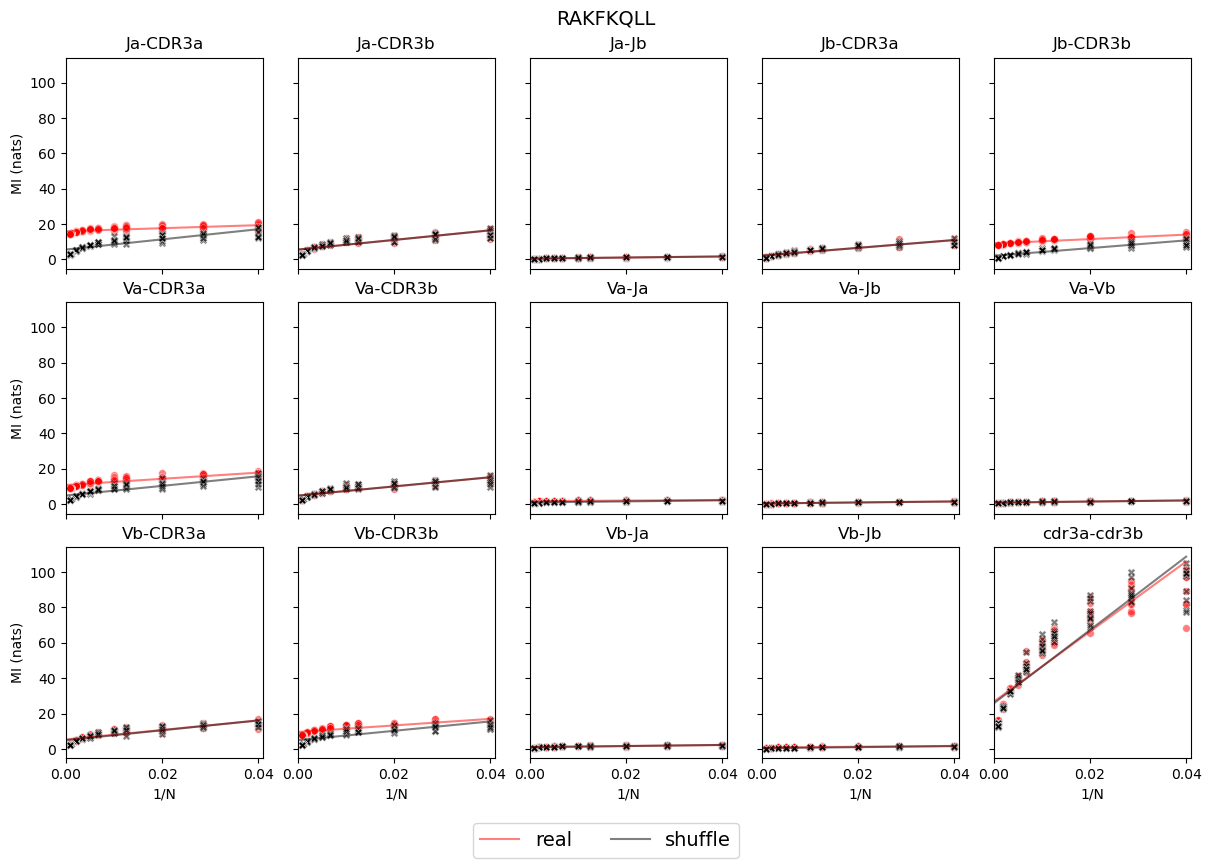

RLRAEAQVK


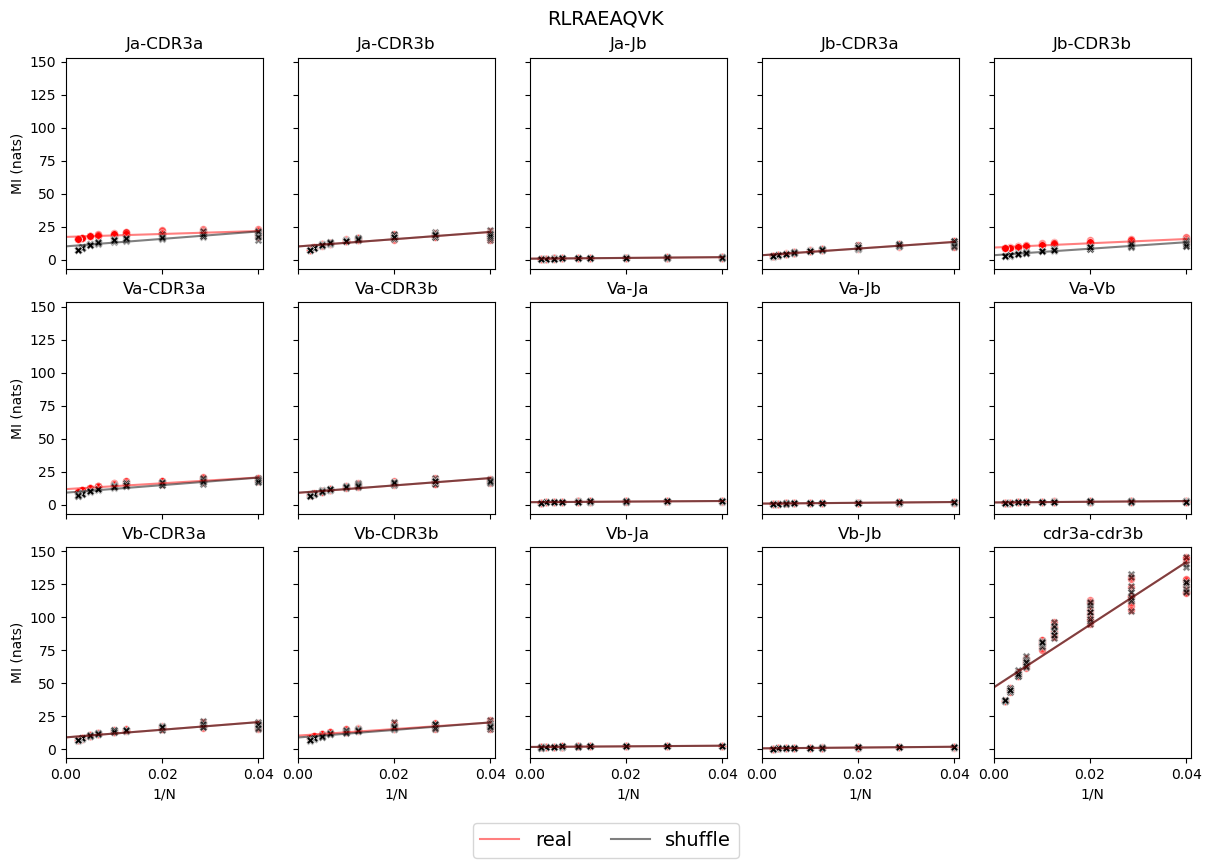

SPRWYFYYL


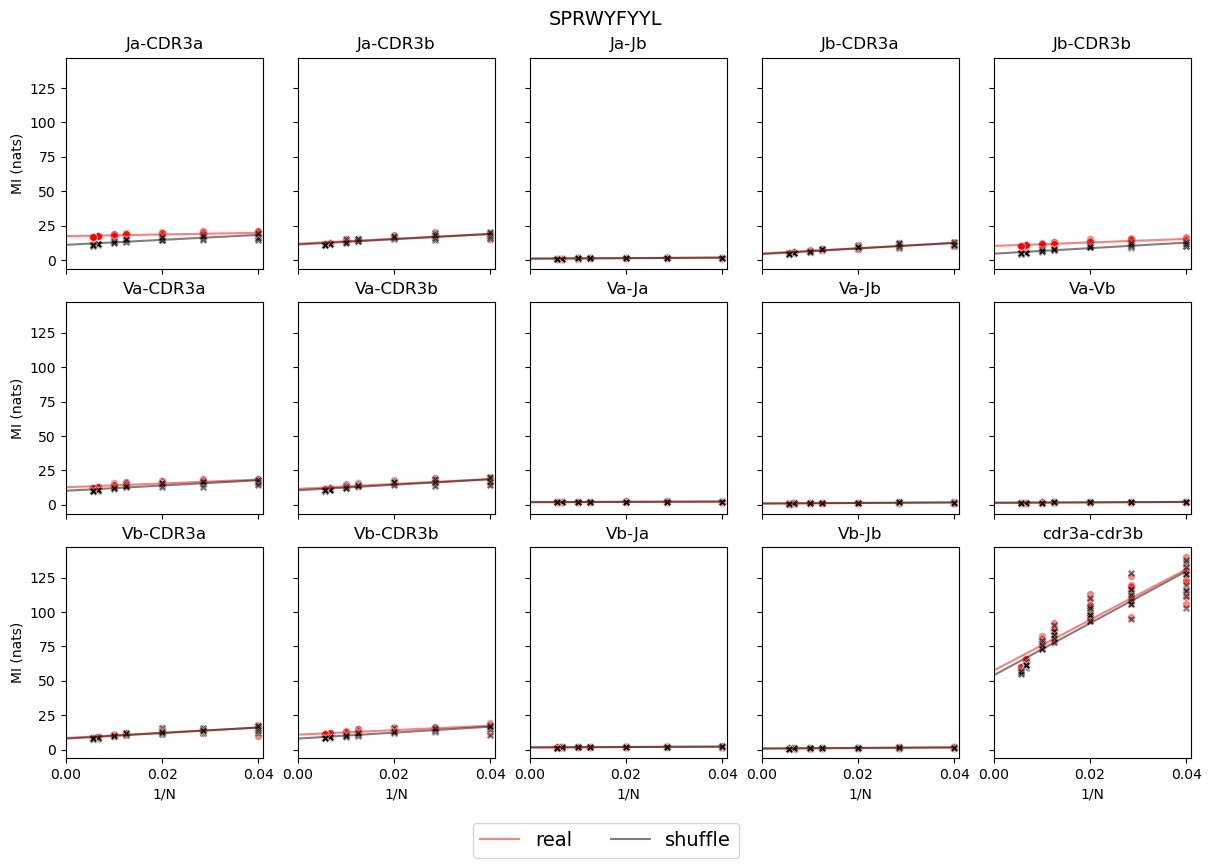

SSLENFRAYV


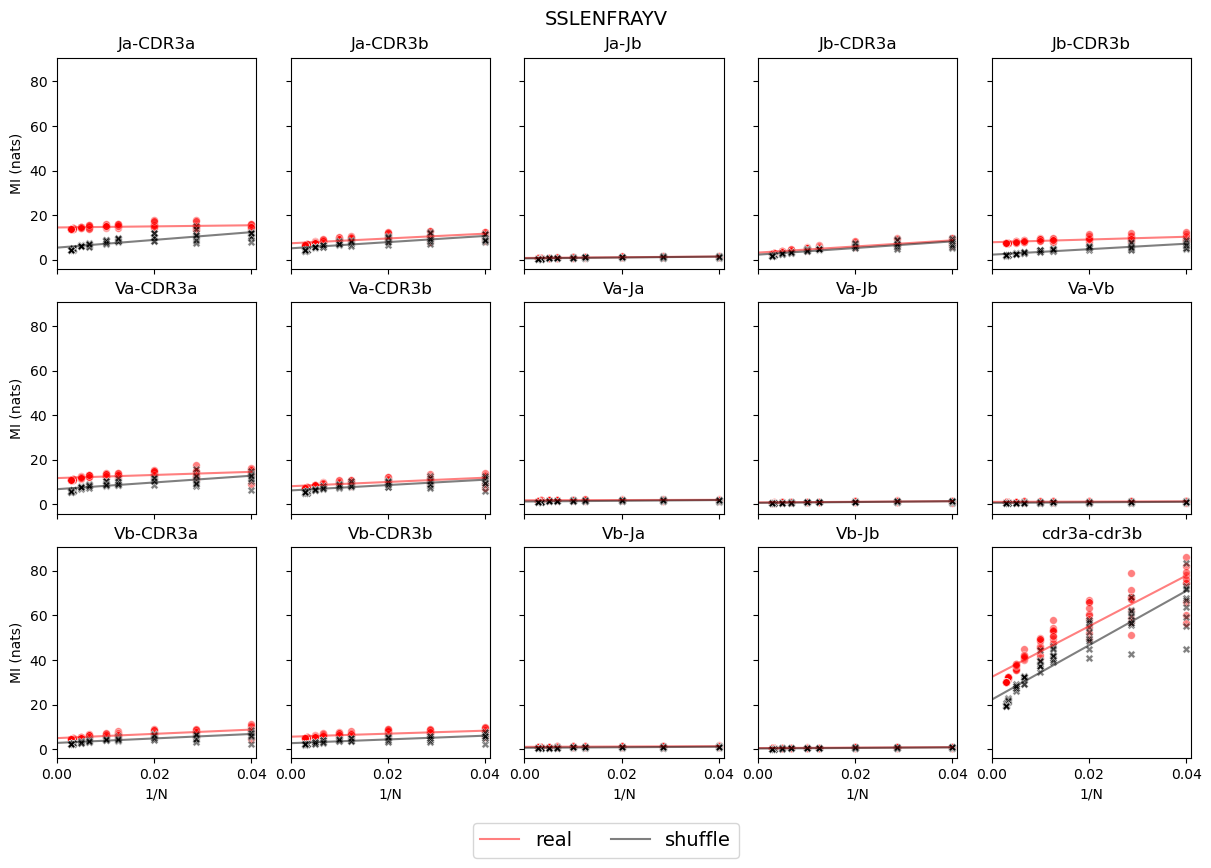

SSPPMFRV


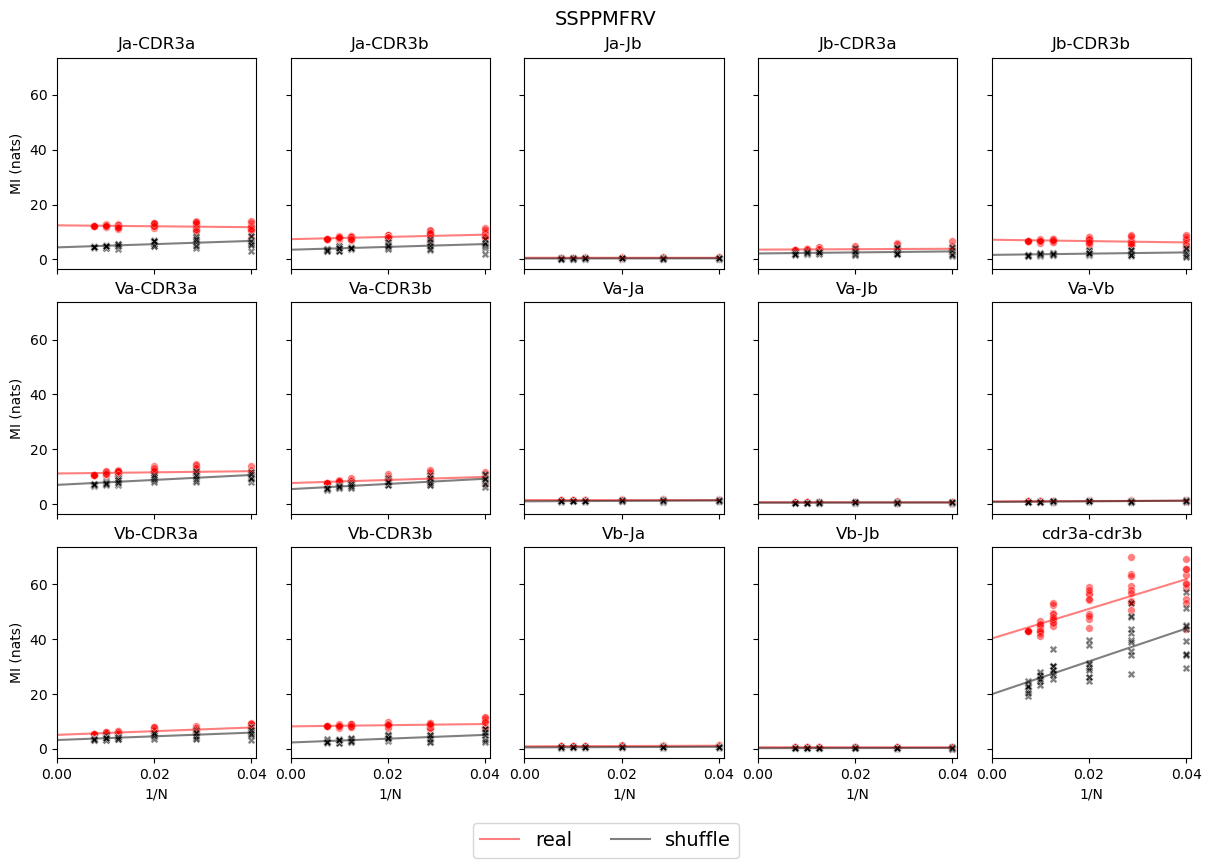

SSYRRPVGI


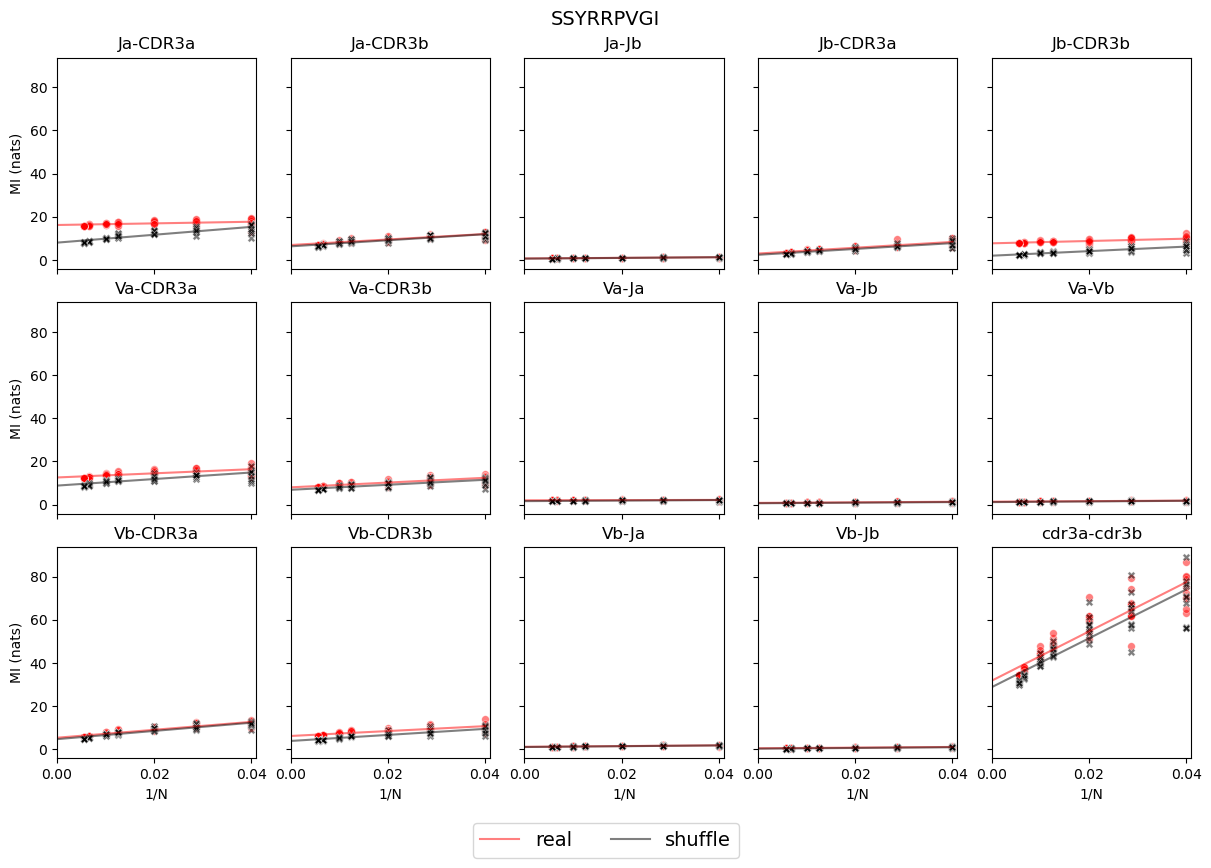

TTDPSFLGRY


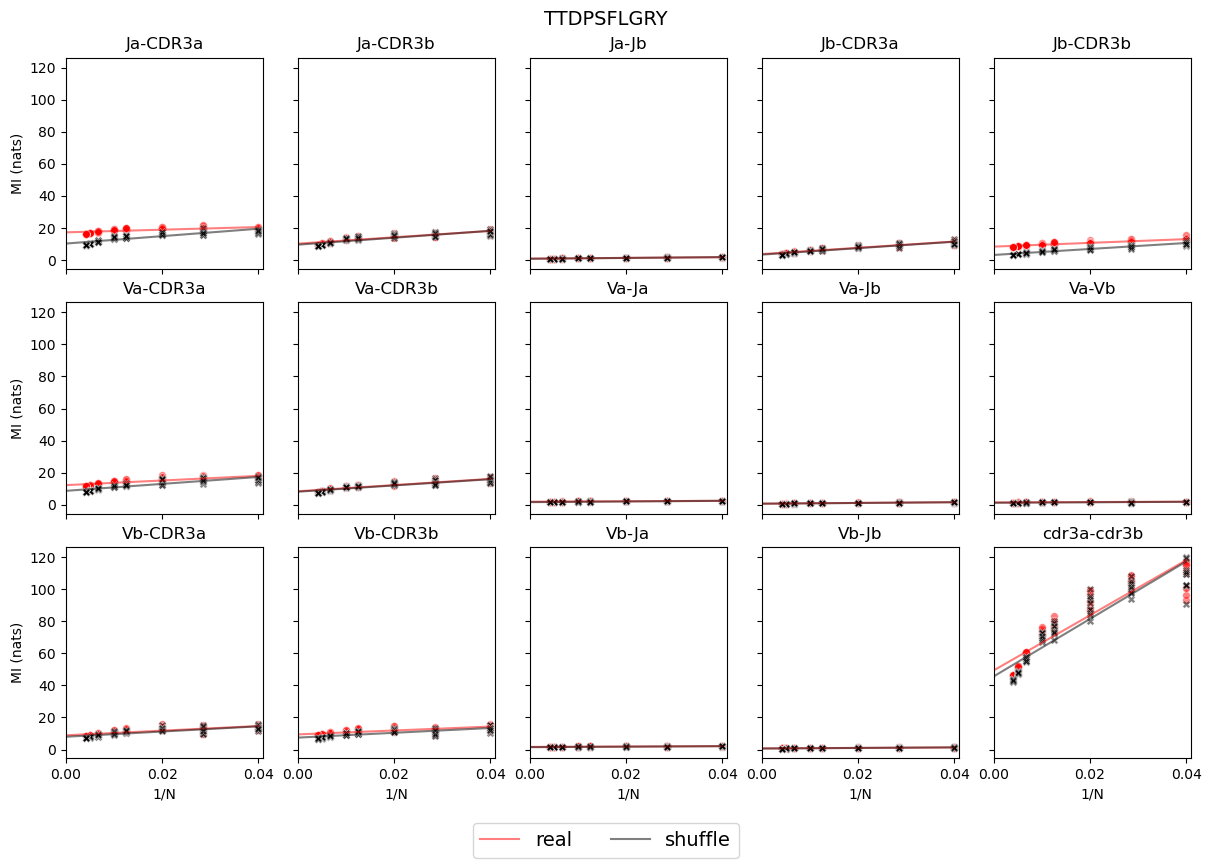

Tanno::A1::naive


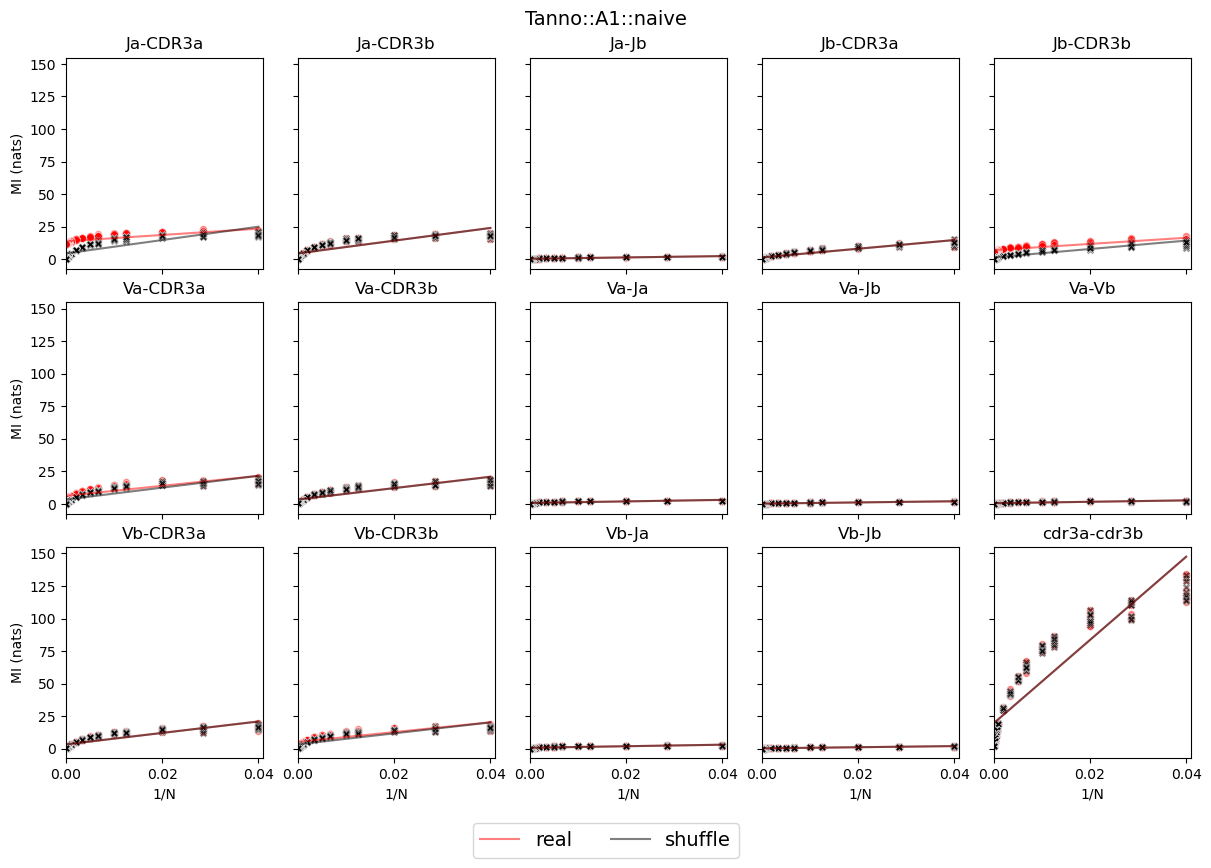

YLQPRTFLL


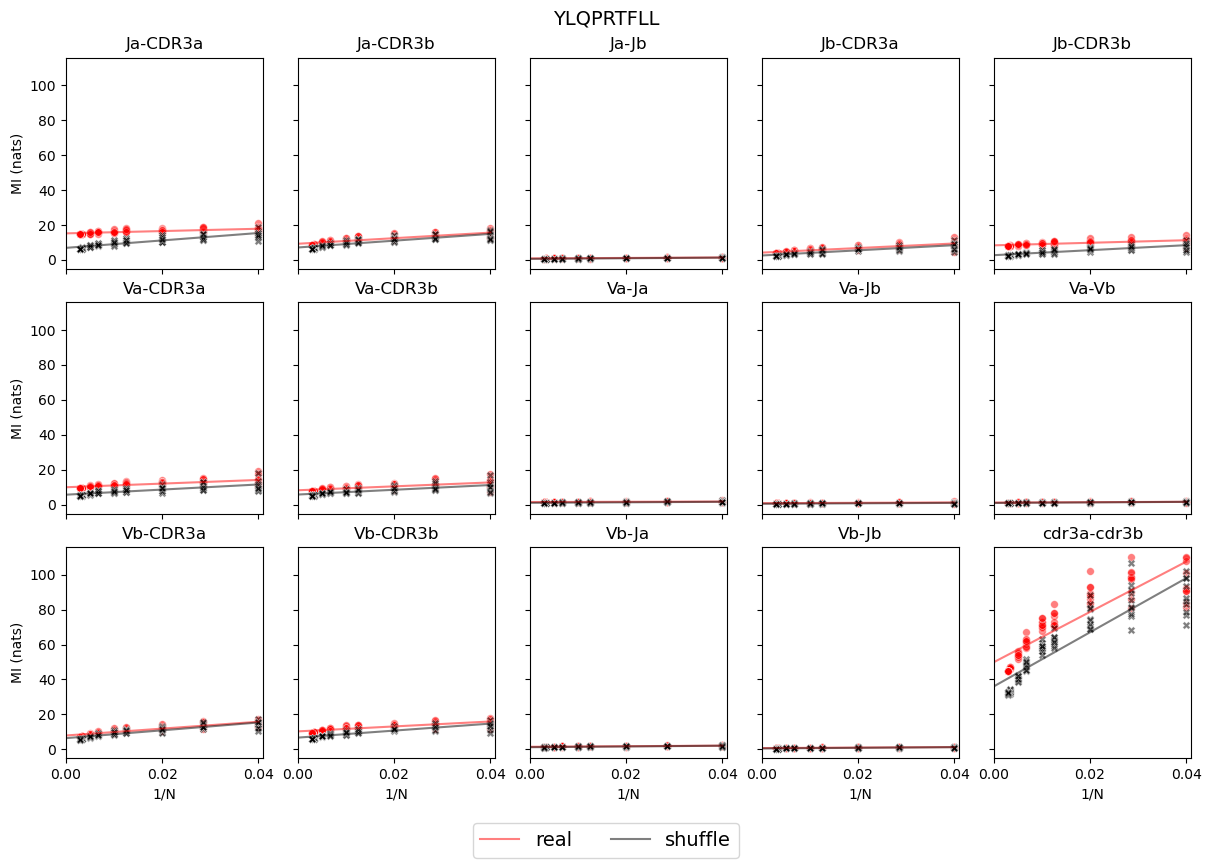

background


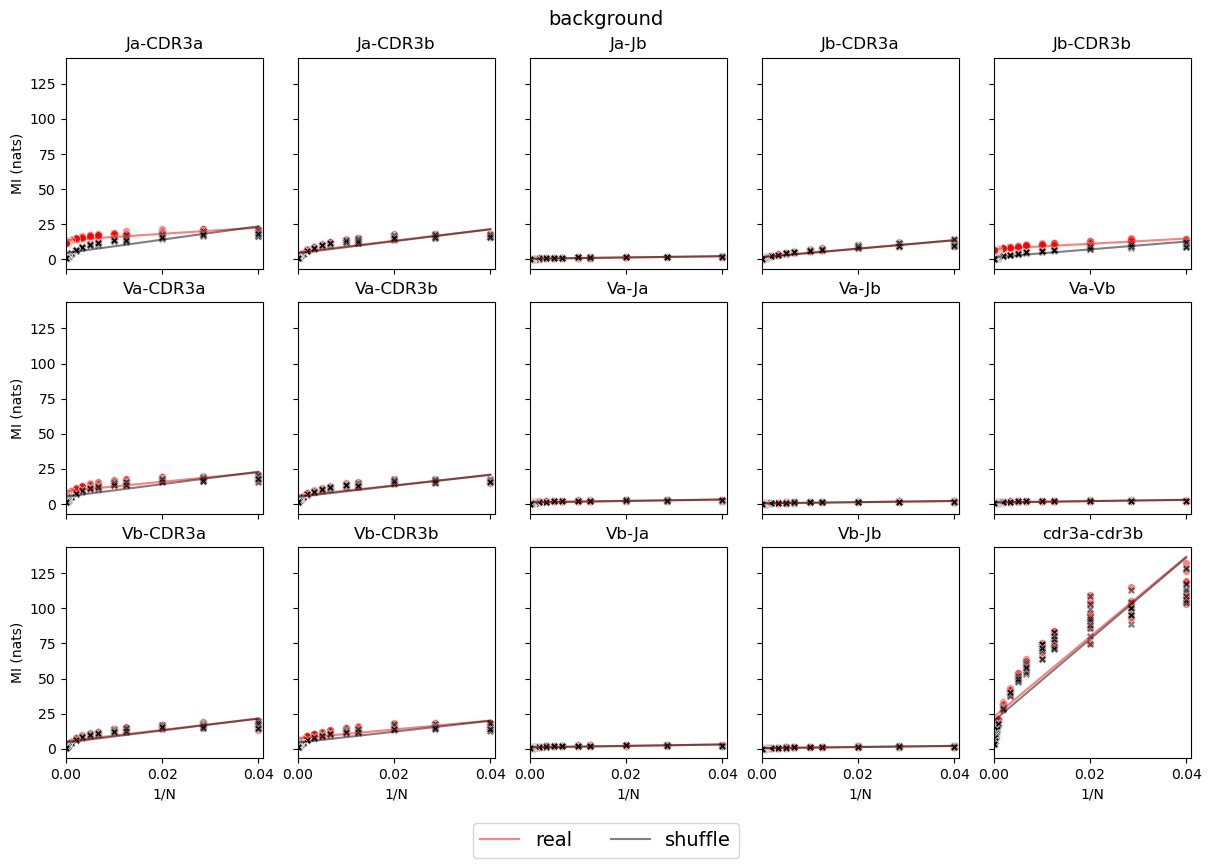

In [15]:
single_val = {}
s = MI2.shape
print(s)
print(MI2['type'].unique().tolist())
MI2_1 = MI2.dropna(subset='type')
print(MI2.shape)
assert s == MI2_1.shape

for ep in sorted(MI2['epitope'].unique().tolist()):
    print(ep)
    f, ax = plt.subplots(ncols=5, nrows=3, figsize=(12,8), sharex=True, sharey=True, constrained_layout=True)
    axs = ax.ravel()
    for i, t in enumerate(sorted(MI2['type'].unique().tolist())):
        # print(i, t)
        ss = MI2.loc[(MI2.epitope == ep) & (MI2.type == t)]
        # print(ss.sort_values(by='value', ascending=False))
        single_val[ep + '_' + t] = fit_linear(ss, t, axs[i])
        # print(single_val)
        axs[i].set_ylabel('')
        if i in [0,5,10]:
            axs[i].set_ylabel('MI (nats)')
        if i >= 10:
            axs[i].set_xlabel('1/N')
        
        h, l = axs[i].get_legend_handles_labels()
        axs[i].get_legend().remove()
    lgd = f.legend(handles = h, labels = l,
            bbox_to_anchor=(0.5, -0.01), loc='upper center', 
            ncol=2, prop={'size': 14})
    title = f.suptitle(ep, fontsize=14)
    if ep == 'GLCTLVAML':
        plt.savefig(f2 + 'MI_estimation_GLC_w_studyspecific_shuffle_wdupl.png',
                    bbox_extra_artists=(lgd,title,), bbox_inches='tight')
    plt.show()


In [16]:
MI

25     \
type        Unnamed: 0                                                                    
cdr3a-cdr3b ELAGIGILTV                [91.32597833187833, 73.53590400418295, 101.156...   
            ELAGIGILTV_shuffle        [96.93599706682748, 74.38483263608167, 99.1531...   
Va-Vb       ELAGIGILTV                [0.9034932211304162, 0.9811022007017058, 0.114...   
            ELAGIGILTV_shuffle        [0.9798749213257937, 0.8147468773673193, 0.214...   
Ja-Jb       ELAGIGILTV                [1.4230451580279992, 1.8942871583297873, 1.561...   
...                                                                                 ...   
Vb-CDR3a    Tanno::A1::naive_shuffle  [14.427601572014044, 15.122502882601179, 15.21...   
Ja-CDR3b    Tanno::A1::naive          [15.573975216080772, 17.00951223458875, 18.706...   
            Tanno::A1::naive_shuffle  [15.594905141831351, 16.793959056946253, 19.67...   
Jb-CDR3a    Tanno::A1::naive          [11.739176827024595, 12.955874318649068, 10.79...   
            Tanno::A1::naive_shuffle  [10.928330136103243, 12.609571749036661, 10.95...   

                                                                                  35     \
type        Unnamed: 0                                                                    
cdr3a-cdr3b ELAGIGILTV                [79.29506652416255, 79.30499688068363, 82.4524...   
            ELAGIGILTV_shuffle        [82.27730772438514, 79.0779699048589, 82.69674...   
Va-Vb       ELAGIGILTV                [0.5361607360762769, 0.6297648576435475, 0.638...   
            ELAGIGILTV_shuffle        [0.44199396847615313, 0.6297648576435477, 0.52...   
Ja-Jb       ELAGIGILTV                [1.250523962758746, 1.4477916695828243, 1.9310...   
...                                                                                 ...   
Vb-CDR3a    Tanno::A1::naive_shuffle  [14.386588382170718, 17.257244356447284, 17.03...   
Ja-CDR3b    Tanno::A1::naive          [17.54019677219878, 19.091698208974677, 18.050...   
            Tanno::A1::naive_shuffle  [17.401954508469032, 19.13130661929238, 18.014...   
Jb-CDR3a    Tanno::A1::naive          [10.631627976859503, 10.800999075053808, 11.27...   
            Tanno::A1::naive_shuffle  [10.469389866560409, 11.10406548012522, 11.568...   

                                                                                  50     \
type        Unnamed: 0                                                                    
cdr3a-cdr3b ELAGIGILTV                [78.42790501148838, 84.07430984716325, 76.3974...   
            ELAGIGILTV_shuffle        [76.27033474300615, 78.81004922941999, 77.5415...   
Va-Vb       ELAGIGILTV                [0.5566585466290798, 0.6453525745828703, 0.352...   
            ELAGIGILTV_shuffle        [0.6712310969221462, 0.6057772951043426, 0.246...   
Ja-Jb       ELAGIGILTV                [1.4875197113711547, 1.535691237605092, 1.6842...   
...                                                                                 ...   
Vb-CDR3a    Tanno::A1::naive_shuffle  [14.66326574524663, 14.772200063284469, 14.191...   
Ja-CDR3b    Tanno::A1::naive          [16.814438943827657, 16.774302334363906, 18.66...   
            Tanno::A1::naive_shuffle  [16.824903906702946, 16.5266958200783, 18.6631...   
Jb-CDR3a    Tanno::A1::naive          [9.950808531217751, 9.251585500327536, 9.28059...   
            Tanno::A1::naive_shuffle  [9.7835607132045, 9.463816553620447, 9.0234050...   

                                                                                  80     \
type        Unnamed: 0                                                                    
cdr3a-cdr3b ELAGIGILTV                [65.37704752629958, 66.39062437606376, 65.4704...   
            ELAGIGILTV_shuffle        [66.03875054517704, 64.39801251808333, 64.9226...   
Va-Vb       ELAGIGILTV                [0.39935032219589467, 0.5558053032261152, 0.52...   
            ELAGIGILTV_shuffle        [0.4153124457451049, 0.53638353652685

In [17]:
MI = pd.DataFrame(single_val, index = ['real', 'shuffle']).T
MI.to_csv('data/output/mutual_info/estimated_mutual_info_all_epitopes_w_studyspecific_shuffle_wdupl.csv')